**Libraries**

In [1]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

from pathlib import Path

import numpy as np
from numpy.typing import NDArray
import pandas as pd

from bloodmoon.types import CoordEquatorial
from bloodmoon.io import simulation_files
from bloodmoon.coords import shift2angle, equatorial2shift
from bloodmoon.mask import CodedMaskCamera
from bloodmoon.mask import codedmask, count
from bloodmoon.mask import variance, snratio

import darksun as ds
from darksun.types import Tag
from darksun.data import Log, DataLoader, CatalogueLoader
from darksun.benchmarking import dict2df
from darksun.utils import savefig_to

**Notebook's General Variables**

In [2]:
# save plot and images
SAVE_TO: str | Path = '/home/edoardo/Desktop/detector_smoothing/smoothing'
SAVE_THINGS: bool = False

ANALYSIS_CAM1A: bool = True
ANALYSIS_CAM1B: bool = True

**Mask and Data Specifics**

In [3]:
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

SKYFIELD: str = "GalacticCentre"
DATA_FITS: str = "galctr_rxte-sax_mask_050_1040x17_fmin0.0945_2-50keV_1ks"
#DATA_FITS: str = "galctr_rxte-sax_mask_050_1040x17_2-50keV_1ks"
#DATA_FITS: str = "galctr_rxte-sax_2-50keV_mask_050_1040x17_opaquemask_infdet"

ANALYSIS_ID: str = "singleCAM_iros_upx5upy1_newOptimiser_smoothing"

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "reconstructed"

UPS_X: int = 5
UPS_Y: int = 1

VIGNETTING: bool = True
PSFY: bool = True

**Analysis Methods**

In [4]:
def extract_catalogue_angular_coords(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> pd.DataFrame:
    """
    Extracts the catalogue sources angular coords.
    """
    angles_x, angles_y = [], []
    for sourceID in log.log['ID']:
        anglex, angley = (
            ds.source_angular_coords(sourceID, catalogue, sdl, camera)
            if sourceID in catalogue.DLdata['ID']
            else (np.nan, np.nan)
        )
        angles_x.append(anglex)
        angles_y.append(angley)
        
    df = pd.DataFrame(
        {'ID': log.log['ID'], 'angle_x': angles_x, 'angle_y': angles_y}
    )
    return df


def get_angularcoords_residues(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> tuple[NDArray, NDArray]:
    """
    Computes the angular coords residues between the IROS
    sources and the catalogue sources in [arcmin].
    """
    angular_coords = extract_catalogue_angular_coords(log, catalogue, sdl, camera)
    angles_x, angles_y = map(
        np.array, (angular_coords['angle_x'], angular_coords['angle_y']),
    )
    res_x, res_y = (
        60 * np.abs(np.array(log.log['angle_x']) - angles_x),
        60 * np.abs(np.array(log.log['angle_y']) - angles_y),
    )
    return res_x, res_y


def extract_catalogue_fluences(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Extracts the catalogue sources fluences.
    """
    fluences = []
    for sourceID in log.log['ID']:
        fluence = (
            ds.source_fluence(sourceID, catalogue, sdl, camera, verbose)
            if sourceID in catalogue.DLdata['ID']
            else np.nan
        )
        fluences.append(fluence)
        
    df = pd.DataFrame(
        {'ID': log.log['ID'], 'fluence': fluences}
    )
    return df


def get_fluence_residues(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    verbose: bool = True,
) -> NDArray:
    """
    Computes the percentage fluence residues between the IROS
    and the catalogue sources.
    """
    df = extract_catalogue_fluences(log, catalogue, sdl, camera, verbose)
    fluences = np.array(df['fluence'])
    res = np.array(log.log['fluence']) - fluences
    return res * 100 / fluences


def reconstruction_data(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Generates a Dataframe with output data from IROS.
    """
    theta_res_x, theta_res_y = get_angularcoords_residues(
        log, catalogue, sdl, camera,
    )
    fluence_res = get_fluence_residues(
        log, catalogue, sdl, camera, verbose,
    )
    dmap = {
        log.name: {
            'ID': log.log['ID'],
            'Brightest': log.log['id_brightest'],
            'SNR': log.log['snr'],
            'DthetaX [arcmin]': theta_res_x,
            'DthetaY [arcmin]': theta_res_y,
            'Dfluence [%]': fluence_res,
        }
    }
    return dict2df(dmap)

**Load Mask and Data**

In [5]:
# load filepaths
mask_path, simul_data, save_path = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
    run_name=ANALYSIS_ID,
)

wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)

filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)

## USING BULK MASK with 1.5 mm cover ##


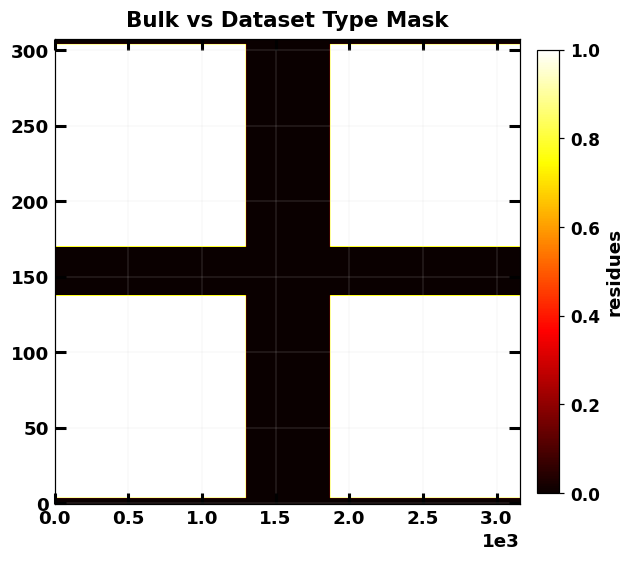

In [6]:
ds.image_plot(
    ds.map4image(
        img=wfm.bulk,
        title='Bulk vs Dataset Type Mask',
        cbarlabel='residues',
        img_kwargs={
            'aspect': wfm.shape_detector[1] / wfm.shape_detector[0],
            'cmap': 'hot',
        },
    )
)

In [7]:
# data from camera A
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET])
catalogueA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])
true_sky_camA, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1A_TEST_{ANALYSIS_ID}.fits")
res_sky_camA, _ = ds.load_sky(save_path + f"skyRES_IROS_CAM1A_TEST_{ANALYSIS_ID}.fits")

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


In [8]:
# data from camera B
sdlB = ds.get_data(filepaths[ID_CAMERA_B][DATASET])
catalogueB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])
true_sky_camB, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1B_TEST_{ANALYSIS_ID}.fits")
res_sky_camB, _ = ds.load_sky(save_path + f"skyRES_IROS_CAM1B_TEST_{ANALYSIS_ID}.fits")

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


In [9]:
log_camA, log_camB = ds.load_database(save_path + f"IROS_sources_database_TEST_{ANALYSIS_ID}.fits")

# Loading data...
# Loading completed!


In [ ]:
# sources data + angular coords residues plot
reconstruction_data(
    log=log_camA,
    catalogue=catalogueA,
    sdl=sdlA,
    camera=wfm,
    verbose=False,
)

Selected 1095715/2328920 photons.
Selected 122429/2328920 photons.
Selected 88282/2328920 photons.
Selected 76309/2328920 photons.
Selected 67104/2328920 photons.
Selected 48328/2328920 photons.
Selected 38471/2328920 photons.
Selected 37053/2328920 photons.
Selected 38045/2328920 photons.
Selected 34006/2328920 photons.
Selected 31829/2328920 photons.
Selected 19859/2328920 photons.
Selected 22087/2328920 photons.
Selected 19877/2328920 photons.
Selected 11633/2328920 photons.
Selected 6795/2328920 photons.
Selected 8315/2328920 photons.
Selected 7247/2328920 photons.
Selected 8912/2328920 photons.


CAM1A                                               \
                ID       Brightest         SNR DthetaX [arcmin]   
0            scox1           scox1  754.386106         0.085684   
1            gx5-1           gx5-1   72.366855         0.075788   
2          gx349+2         gx349+2   53.549798         0.322842   
3           gx17+2          gx17+2   47.383488         0.255613   
4            gx9+1           gx9+1   44.054758         0.131884   
5          gx340+0         gx340+0   30.688197         0.322027   
6           gx13+1          gx13+1   24.429209         0.246399   
7        x1820-303       x1820-303   24.449036         0.312297   
8            gx3+1           gx3+1   23.830559         0.097182   
9      groj1655-40     groj1655-40   22.566257         0.255192   
10           gx9+9           gx9+9   18.989536         0.014996   
11       x1705-440       x1705-440   16.208857         0.117172   
12           cirx1           cirx1   19.895647         0.384704   
13       x1735-444       x1735-444   11.740172         0.569432   
14         gx354-0         gx354-0    7.903150         0.151327   
15       x1630-472       x1630-472    6.029730         0.326856   
16    lemx-cam1aS1    lemx-cam1aS1    5.041986              NaN   
17     grs1915+105     grs1915+105   11.789875         0.275641   
18       x1636-536       x1636-536    5.501233         0.504282   
19  igrj17091-3624  igrj17091-3624    5.015493         0.356116   

                                  
   DthetaY [arcmin] Dfluence [%]  
0          0.016723    -0.524309  
1          0.098236    -1.822841  
2          5.398838     5.076605  
3          2.994192     1.005062  
4          2.625883     2.947376  
5          4.079782    -0.913012  
6          6.112196     3.460721  
7          4.717723    13.332736  
8          4.627520     2.696154  
9          8.898931     5.567419  
10         8.681625    -7.988729  
11        17.287923    38.609647  
12         0.510309   -12.039101  
13         0.654178    -6.790887  
14        14.006188    -4.920146  
15        26.860219    20.536194  
16              NaN          NaN  
17         8.147443   -22.034943  
18        17.462585    -4.877364  
19        51.806098   -21.044376

In [ ]:
# sources data + angular coords residues plot
reconstruction_data(
    log=log_camB,
    catalogue=catalogueB,
    sdl=sdlB,
    camera=wfm,
    verbose=False,
)

Selected 1003384/2255740 photons.
Selected 123322/2255740 photons.
Selected 87797/2255740 photons.
Selected 81137/2255740 photons.
Selected 66828/2255740 photons.
Selected 51373/2255740 photons.
Selected 39083/2255740 photons.
Selected 39375/2255740 photons.
Selected 36547/2255740 photons.
Selected 32769/2255740 photons.
Selected 34603/2255740 photons.
Selected 21572/2255740 photons.
Selected 23461/2255740 photons.
Selected 21689/2255740 photons.
Selected 11905/2255740 photons.
Selected 8298/2255740 photons.
Selected 8683/2255740 photons.
Selected 8196/2255740 photons.
Selected 7563/2255740 photons.
Selected 4530/2255740 photons.
Selected 5956/2255740 photons.
Selected 7823/2255740 photons.


CAM1B                                               \
                ID       Brightest         SNR DthetaX [arcmin]   
0            scox1           scox1  705.523780         0.132576   
1            gx5-1           gx5-1   76.839836         0.040711   
2          gx349+2         gx349+2   55.264734         0.062487   
3           gx17+2          gx17+2   51.186673         0.033685   
4            gx9+1           gx9+1   42.562666         0.411175   
5          gx340+0         gx340+0   35.269574         0.127914   
6           gx13+1          gx13+1   26.919927         0.338008   
7            gx3+1           gx3+1   24.029106         0.046110   
8        x1820-303       x1820-303   23.029320         0.048350   
9            gx9+9           gx9+9   20.859713         0.069060   
10     groj1655-40     groj1655-40   20.278403         0.296255   
11       x1735-444       x1735-444   15.566546         0.390208   
12           cirx1           cirx1   24.777971         0.457588   
13       x1705-440       x1705-440   13.860123         0.175988   
14    lemx-cam1bS1    lemx-cam1bS1   11.135805              NaN   
15         gx354-0         gx354-0    7.457758         0.221863   
16  igrj17091-3624  igrj17091-3624    6.511707         0.466973   
17       x1636-536       x1636-536    7.639780         0.115016   
18           serx1           serx1    8.941388         0.029878   
19    lemx-cam1bS2    lemx-cam1bS2    6.564601              NaN   
20       x1630-472       x1630-472    5.667770         0.309477   
21       x1702-429       x1702-429    5.208472         0.861923   
22    lemx-cam1bS3    lemx-cam1bS3    5.094215              NaN   
23         gx339-4         gx339-4    5.204540         0.239802   
24     grs1915+105     grs1915+105   13.296331         0.530312   
25    lemx-cam1bS4    lemx-cam1bS4    5.057561              NaN   

                                  
   DthetaY [arcmin] Dfluence [%]  
0          0.577066    -1.146158  
1          1.159383    -4.153642  
2          3.213751     1.635944  
3          0.260356     1.207783  
4          2.459395     6.968099  
5          4.197202     1.425636  
6          6.209383    16.591550  
7         13.643065   -11.506704  
8          6.474195    -1.748484  
9          0.095500    -2.523385  
10        10.755782    -5.690182  
11        14.983773     9.385669  
12         1.447230     4.005719  
13         5.093307    -7.025453  
14              NaN          NaN  
15         5.115837     3.770255  
16        22.886750    24.933624  
17        12.024017    11.912918  
18        12.458660    26.486279  
19              NaN          NaN  
20         7.057737    -2.327104  
21        78.515245   103.161098  
22              NaN          NaN  
23        11.070965    44.430520  
24         4.617992   -13.813425  
25              NaN          NaN

In [12]:
assert False

AssertionError: 

**Analysis for LEM-X Camera A**

In [ ]:
assert ANALYSIS_CAM1A

In [ ]:
angular_coords = extract_catalogue_angular_coords(log_camA, wfm, catalogueA, sdlA)
cat_theta_x, cat_theta_y = map(
    np.array, (angular_coords['THETAX'], angular_coords['THETAY']),
)

theta_res_x, theta_res_y = get_angularcoords_residues(
    log=log_camA,
    catalogue=catalogueA,
    sdl=sdlA,
    camera=wfm,
)

tags_x = tuple(
    Tag(name, res, theta) for name, res, theta in zip(
        log_camA.log['ID'], theta_res_x, cat_theta_x,
    )
)
tags_y = tuple(
    Tag(name, res, theta) for name, res, theta in zip(
        log_camA.log['ID'], theta_res_y, cat_theta_y,
    )
)
dmapx = ds.map4plot(
    arrs=theta_res_x,
    title=f'{log_camA.name} X-Axis Angular Residues (abs values)',
    xlabel='$\\theta_{{x}}$ off-axis angle [deg]',
    ylabel='$\\Delta\\theta_{{x}}$ residues [arcmin]',
    x=cat_theta_x,
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tags_x,
)
dmapy = ds.map4plot(
    arrs=theta_res_y,
    title=f'{log_camA.name} Y-Axis Angular Residues (abs values)',
    xlabel='$\\theta_{{y}}$ off-axis angle [deg]',
    ylabel='$\\Delta\\theta_{{y}}$ residues [arcmin]',
    x=cat_theta_y,
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tags_y,
)

ds.plot(
    (dmapx, dmapy),
    ncols=2,
    save_to=(
        savefig_to(SAVE_TO, f'angularRes_{ID_CAMERA_A.upper()}')
        if SAVE_THINGS else None
    ),
)

In [ ]:
# sources profiles during IROS + residues heatmaps
cropy, cropx = (
    int(wfm.specs.slit_deltay * UPS_Y / wfm.specs.mask_deltay + 5),
    int(wfm.specs.slit_deltax * UPS_X / wfm.specs.mask_deltax + 5),
)
ds.reconstructed_sources_profiles(
    true_sky=true_sky_camA,
    log=log_camA,
    crp=(cropy, cropx),
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
    save_to=SAVE_TO if SAVE_THINGS else None,
)

In [ ]:
slit_fine, slit_coarse = ds.psf_extension(wfm)

ds.reconstruction_sources_heatmaps(
    true_sky=true_sky_camA,
    log=log_camA,
    crp=(slit_coarse + 5, slit_fine + 5),
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
    save_to=SAVE_TO if SAVE_THINGS else None,
)

In [ ]:
# sky significance distr. for true sky and at the last IROS iteration
detector_camA = count(wfm, sdlA.DLdata)[0]
varmap = variance(wfm, detector_camA)

ycut, xcut = UPS_Y * 30, UPS_X * 20
true_skysnr_camA = ds.unframe(snratio(true_sky_camA, varmap), ycut, xcut)
res_skysnr_camA = ds.unframe(snratio(res_sky_camA, varmap), ycut, xcut)

num_bins = 1000
density = True
hist_true_skysnr, bins = np.histogram(true_skysnr_camA, bins=num_bins, density=density)
hist_res_skysnr, _ = np.histogram(res_skysnr_camA, bins=bins, density=density)


x0, xN = -20, 50
bins_slice, hist_slice = ds.config_distr_limits(bins, x0, xN)

dmap1_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_res_skysnr[hist_slice]),
    title=f'Significance distr. {ID_CAMERA_A.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'IROS'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
)
dmap2_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_res_skysnr[hist_slice]),
    title=f'Significance distr. (yscale log) {ID_CAMERA_A.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'IROS'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
    yscale='log',
)
ds.plot(
    dmaps=(dmap1_snr, dmap2_snr),
    ncols=2,
    save_to=(
        savefig_to(SAVE_TO, f'snr_distr_{ID_CAMERA_A.upper()}')
        if SAVE_THINGS else None
    ),
)

**Analysis for LEM-X Camera B**

In [ ]:
assert ANALYSIS_CAM1B

In [ ]:
angular_coords = extract_catalogue_angular_coords(log_camB, wfm, catalogueB, sdlB)
cat_theta_x, cat_theta_y = map(
    np.array, (angular_coords['THETAX'], angular_coords['THETAY']),
)

theta_res_x, theta_res_y = get_angularcoords_residues(
    log=log_camB,
    catalogue=catalogueB,
    sdl=sdlB,
    camera=wfm,
)

tags_x = tuple(
    Tag(name, res, theta) for name, res, theta in zip(
        log_camB.log['ID'], theta_res_x, cat_theta_x,
    )
)
tags_y = tuple(
    Tag(name, res, theta) for name, res, theta in zip(
        log_camB.log['ID'], theta_res_y, cat_theta_y,
    )
)
dmapx = ds.map4plot(
    arrs=theta_res_x,
    title=f'{log_camB.name} X-Axis Angular Residues (abs values)',
    xlabel='$\\theta_{{x}}$ off-axis angle [deg]',
    ylabel='$\\Delta\\theta_{{x}}$ residues [arcmin]',
    x=cat_theta_x,
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tags_x,
)
dmapy = ds.map4plot(
    arrs=theta_res_y,
    title=f'{log_camB.name} Y-Axis Angular Residues (abs values)',
    xlabel='$\\theta_{{y}}$ off-axis angle [deg]',
    ylabel='$\\Delta\\theta_{{y}}$ residues [arcmin]',
    x=cat_theta_y,
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tags_y,
)

ds.plot(
    (dmapx, dmapy),
    ncols=2,
    save_to=(
        savefig_to(SAVE_TO, f'angularRes_{ID_CAMERA_B.upper()}')
        if SAVE_THINGS else None
    ),
)

In [ ]:
# sources profiles during IROS + residues heatmaps
cropy, cropx = (
    int(wfm.specs.slit_deltay * UPS_Y / wfm.specs.mask_deltay + 5),
    int(wfm.specs.slit_deltax * UPS_X / wfm.specs.mask_deltax + 5),
)
ds.reconstructed_sources_profiles(
    true_sky=true_sky_camB,
    log=log_camB,
    crp=(cropy, cropx),
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
    save_to=SAVE_TO if SAVE_THINGS else None,
)

In [ ]:
ds.reconstruction_sources_heatmaps(
    true_sky=true_sky_camB,
    log=log_camB,
    crp=(cropy, cropx),
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
    save_to=SAVE_TO if SAVE_THINGS else None,
)

In [ ]:
# sky significance distr. for true sky and at the last IROS iteration
detector_camB = count(wfm, sdlB.DLdata)[0]
varmap = variance(wfm, detector_camB)

ycut, xcut = UPS_Y * 30, UPS_X * 20
true_skysnr_camB = ds.unframe(snratio(true_sky_camA, varmap), ycut, xcut)
res_skysnr_camB = ds.unframe(snratio(res_sky_camA, varmap), ycut, xcut)

num_bins = 1000
density = True
hist_true_skysnr, bins = np.histogram(true_skysnr_camB, bins=num_bins, density=density)
hist_res_skysnr, _ = np.histogram(res_skysnr_camB, bins=bins, density=density)


x0, xN = None, None
bins_slice, hist_slice = ds.config_distr_limits(bins, x0, xN)

dmap1_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_res_skysnr[hist_slice]),
    title=f'Significance distr. {ID_CAMERA_B.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'IROS'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
)
dmap2_snr = ds.map4plot(
    arrs=(hist_true_skysnr[hist_slice], hist_res_skysnr[hist_slice]),
    title=f'Significance distr. (yscale log) {ID_CAMERA_B.upper()}',
    xlabel='SNR',
    ylabel='density',
    labels=('true', 'IROS'),
    x=bins[bins_slice],
    style='stairs',
    color=('OrangeRed', 'Dodgerblue'),
    yscale='log',
)
ds.plot(
    dmaps=(dmap1_snr, dmap2_snr),
    ncols=2,
    save_to=(
        savefig_to(SAVE_TO, f'snr_distr_{ID_CAMERA_B.upper()}')
        if SAVE_THINGS else None
    ),
)